In [1]:
import numpy as np
import matplotlib as plt

In [16]:

def generate_tree(n, d, s, k, m, seed=None):
    if seed is not None:
        np.random.seed(seed)

    levels = []

    # Level 0
    current_points = np.random.normal(0.0, s, size=(n, d))
    levels.append(current_points)

    current_scale = s

    for depth in range(1, m):
        next_points = []
        current_scale *= k

        for parent in current_points:
            children = np.random.normal(
                loc=parent,
                scale=current_scale,
                size=(n, d)
            )
            next_points.append(children)

        current_points = np.vstack(next_points)
        levels.append(current_points)

    return levels

def plot_tree_colormap(levels, cmap_name="viridis"):
    plt.figure(figsize=(8, 8))
    levels=levels[::-1]
    num_levels = len(levels)
    cmap = plt.get_cmap(cmap_name)

    for depth, pts in enumerate(levels):
        color = cmap(depth / (num_levels - 1))
        plt.scatter(
            pts[:, 0],
            pts[:, 1],
            color=color,
            s=10,
            alpha=0.7
        )

    # colorbar to show depth mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=num_levels-1))
    sm.set_array([])
    #cbar = plt.colorbar(sm,mappable=ScalarMappable)
    #cbar.set_label("Depth")

    plt.title("Hierarchical Gaussian Tree (colored by depth)")
    plt.axis("equal")
    plt.show()


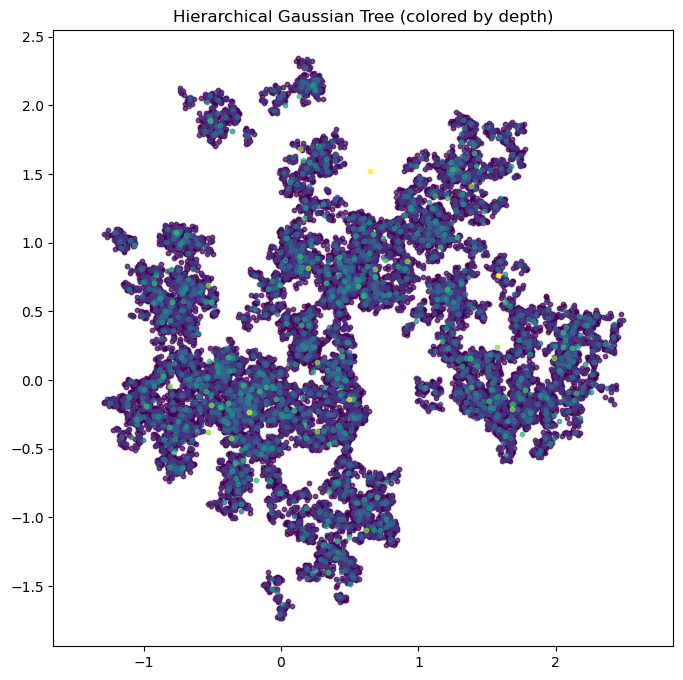

In [17]:
n = 4      # try larger branching
d = 2
s = 1.0
k = 0.5
m = 7      # deeper tree

levels = generate_tree(n, d, s, k, m, seed=42)
plot_tree_colormap(levels)

In [9]:
def generate_tree_with_edges(n, d, s, k, m):
    
    np.random.seed(42)

    levels = []
    edges = []  # (parent_index, child_index) per level

    # Level 0
    current_points = np.random.normal(0.0, s, size=(n, d))
    levels.append(current_points)

    current_scale= s

    for depth in range(1, m):
        next_points = []
        level_edges = []

        current_scale *= k
        child_idx = 0

        for parent_idx, parent in enumerate(current_points):
            children = np.random.normal(
                loc=parent,
                scale=current_scale,
                size=(n, d)
            )

            next_points.append(children)

            # record edges
            for i in range(n):
                level_edges.append((parent_idx, child_idx))
                child_idx += 1

        current_points = np.vstack(next_points)
        levels.append(current_points)
        edges.append(level_edges)
    return levels, edges


def plot_tree_2d(levels, edges):
    plt.figure(figsize=(8, 8))

    # plot points
    for depth, pts in enumerate(levels):
        plt.scatter(pts[:, 0], pts[:, 1], s=15, label=f"Level {depth}", alpha=0.7)

    # plot edges
    for depth, level_edges in enumerate(edges):
        parents = levels[depth]
        children = levels[depth + 1]

        for p_idx, c_idx in level_edges:
            p = parents[p_idx]
            c = children[c_idx]
            plt.plot([p[0], c[0]], [p[1], c[1]], 'k-', alpha=0.2)

    plt.title("Hierarchical Gaussian Tree (2D)")
    plt.legend()
    plt.axis("equal")
    plt.show()



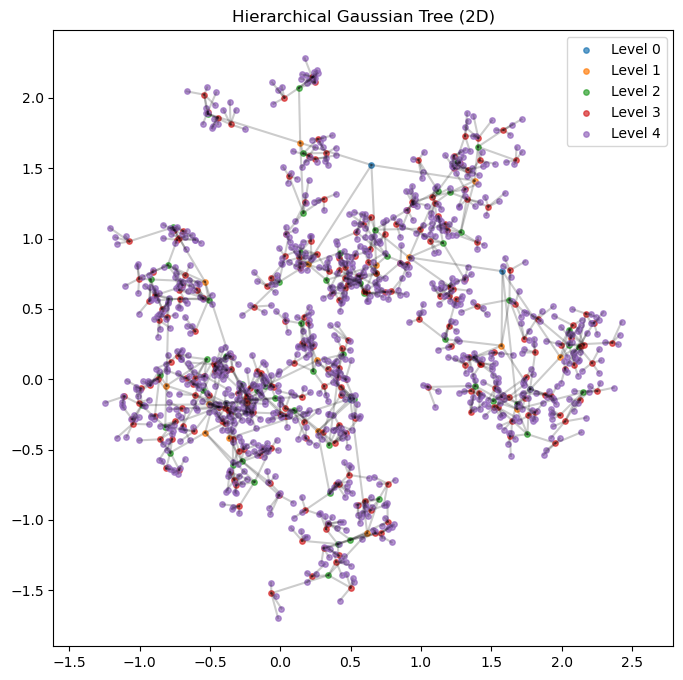

In [23]:
n = 4      # try larger branching
d = 2
s = 1.0
k = 0.5
m = 5      # deeper tree

levels,edges = generate_tree_with_edges(n, d, s, k, m)
plot_tree_2d(levels,edges)


In [12]:
def onedim_tree(n, s, k, m):
   
    levels = np.empty(shape=(0,1))

    # Level 0
    current_points = np.random.normal(0.0, s, size=n)
    levels=np.append(levels,current_points)
    current_scale = s

    for depth in range(1, m):
        next_points = np.array([])
        current_scale *= k

        for parent in current_points:
            children = np.random.normal(
                loc=parent,
                scale=current_scale,
                size=n
            )
            next_points = np.append(next_points, children)
        current_points=next_points   
        levels=np.append(levels, next_points)

    return levels




def plot_tree_1d(levels,bins):
    plt.figure(figsize=(8, 8))
    data =levels.flatten()
    bins = bins

# Compute histogram
    counts, bin_edges = np.histogram(data, bins=bins)

# Convert bin edges to labels (e.g., intervals)
    bin_labels = [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(len(bin_edges)-1)]

# Plot bar chart
    plt.hist(bin_edges[:-1], bin_edges, weights=counts)

    plt.xlabel("Value range")
    plt.ylabel("Frequency")
    plt.title("Distribution of 1D Dataset")
    plt.xticks([])
    plt.tight_layout()

    plt.show()
   


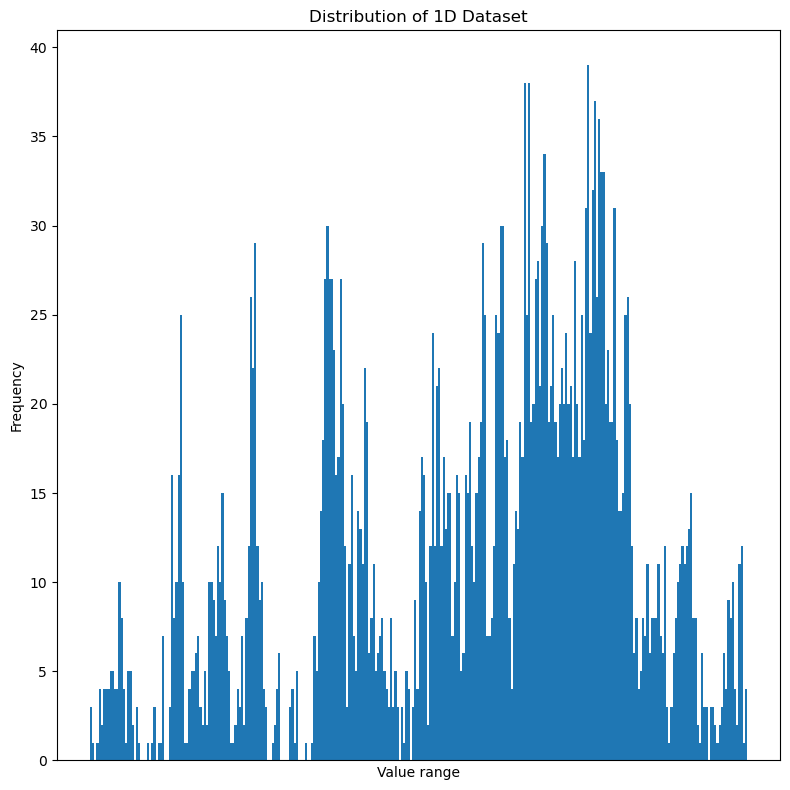

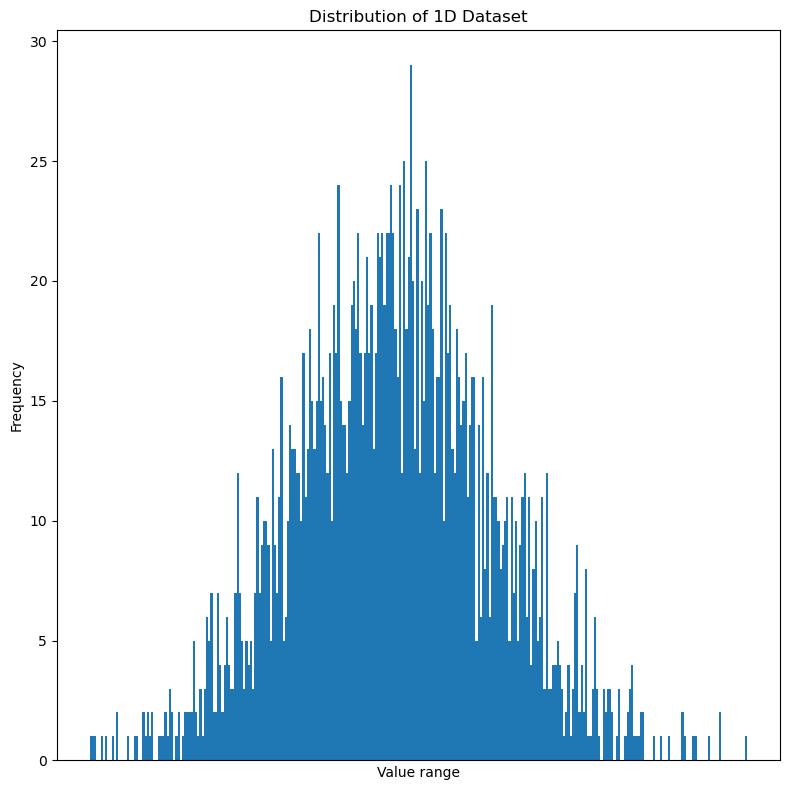

In [13]:
n = 3
d = 2
s = 1.0   
k = 0.4
m =7

levels=onedim_tree(n, s, k, m)
plot_tree_1d(levels,   300)
plot_tree_1d(np.random.normal(0.0, s, size=3**7),300)